# D-Link DIR-X3060Z ↔ three Jetson / Intel 8260 robots

Compare **one D-Link DIR-X3060Z AX3000 Wi-Fi 6 router** with **three mobile robots**, each carrying a Jetson Orin NX, Intel Wireless-AC 8260 card and two user-specified 6 dBi antennas connected by MHF4 pigtails. Both bands use identical coordinates and **20 MHz bandwidth** initially, separating frequency-dependent propagation from bandwidth effects.

**The clients are not Wi-Fi 6:** the Intel 8260 uses 802.11n at 2.4 GHz and 802.11ac at 5 GHz. The router's AX3000 rating is not an individual robot's link rate. This notebook models 2×2 single-user channels, not ax OFDMA or multi-user scheduling.

Reuse the LoRa pilot's public regions: corridors, library, atrium/walkway and public computing suite; exclude labs, lecture halls, furniture and the upstairs void. The router starts in the ground-floor atrium at 1.5 m. The three initial robot antenna centres are at 1.3 m in a corridor, library and upstairs public computing suite. These are **stationary snapshots** of mobile robots: no trajectory, Doppler, robot chassis or changing orientation is simulated. Change the heights to match actual mounts.

**VS Code:** choose `nvidia/.venv-lora/bin/python`, then Run All. CPU tracing and saved Matplotlib figures work without WebGL. The optional 3D widget opens inside the notebook. See [README](README.md).

Outputs: downlink/uplink signal and thermal-noise SNR, band comparison, 2×2 channel diagnostics, an idealized information-rate bound, floor plans, static 3D placement and downlink maps. This is a propagation/PHY study, not a packet emulator, driver benchmark, throughput forecast or contention simulation.

In [1]:
from pathlib import Path
import importlib.metadata
import json
import math
import drjit as dr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Rectangle
from IPython.display import display, Markdown
import mitsuba as mi

# Restart the kernel before changing variant. CPU works without CUDA or WebGL.
mi.set_variant("llvm_ad_mono_polarized")
from sionna.rt import (load_scene, PlanarArray, Transmitter, Receiver, PathSolver,
                       PolarizedAntennaPattern, register_antenna_pattern)

def find_repo_root(start=Path.cwd()):
    for parent in (start, *start.parents):
        for candidate in (parent, parent / "sionna-lora-ext"):
            if (candidate / "assets/sionna/scene_2400MHz.xml").is_file():
                return candidate
    raise FileNotFoundError("Open this notebook from the nvidia or sionna-lora-ext workspace.")

REPO_ROOT = find_repo_root()
SCENE_PATH = REPO_ROOT / "assets/sionna/scene_2400MHz.xml"
print("Sionna RT", importlib.metadata.version("sionna-rt"), "|", mi.variant())
print(SCENE_PATH)

Sionna RT 2.1.0 | llvm_ad_mono_polarized
/home/ubuntu/Desktop/sk/nvidia/sionna-lora-ext/assets/sionna/scene_2400MHz.xml


## Confirmed hardware and remaining assumptions

Your hardware: **one DIR-X3060Z AX3000 router; three Intel Wireless-AC 8260-equipped robots; two 6 dBi antennas per robot, with MHF4 pigtails**. The [Intel 8260 specifications](https://www.intel.com/content/www/us/en/products/sku/86068/intel-dual-band-wirelessac-8260/specifications.html) confirm 2×2, 2.4/5 GHz, Wi-Fi 5 and a maximum advertised 867 Mbit/s. [Intel's adapter guide](https://www.intel.com/content/dam/support/us/en/documents/network-and-i-o/wireless-networking/intel-wifi-adapter-information-guide.pdf) distinguishes 2.4 GHz b/g/n from 5 GHz ac/n. A Wi-Fi 6 AP does not turn these clients into ax devices. The card does not support MU-MIMO; this study uses single-user spatial channels.

Intel cards use Linux [iwlwifi](https://wireless.docs.kernel.org/en/latest/en/users/drivers/iwlwifi.html). The Jetson carrier, kernel and firmware must support the actual card; they do not determine its antenna gain. The **6 dBi rating is user-supplied** and is provisionally applied to each antenna on both bands until a per-band gain/pattern datasheet is available. MHF4 identifies the feed connector, not cable attenuation. Six dBi per antenna is not 12 dBi simply because there are two antennas. These must be dual-band Wi-Fi radiators, not the earlier LoRa antennas.

The router's exact per-band conducted power, internal feed loss, antenna pattern and active antenna arrangement have not been verified. A two-element router array is an effective **2×2 link surrogate**, not a reconstruction of every DIR-X3060Z antenna. Remaining values are editable assumptions, not vendor specifications:

| Parameter | 2.4 GHz | 5 GHz | Basis |
|---|---:|---:|---|
| Centre frequency | 2.437 GHz / channel 6 | 5.180 GHz / channel 36 | Chosen 20 MHz comparison |
| Total conducted router TX power | 20 dBm | 20 dBm | Assumed across active TX chains |
| Total conducted Intel 8260 TX power | 17 dBm | 17 dBm | Assumed, not measured driver output |
| Router antenna peak gain per element | 3 dBi | 3 dBi | Assumed |
| Robot antenna peak gain per element | 6 dBi | 6 dBi | User rating; band dependence unverified |
| Router feed loss per chain | 0.5 dB | 0.5 dB | Assumed |
| Robot MHF4 pigtail/connector loss per chain | 1 dB | 1.5 dB | Assumed pending cable specs |
| Router / client noise figure at RF connector | 7 / 7 dB | 7 / 7 dB | Assumed |

Antennas start upright. The azimuth-omnidirectional surrogate narrows its elevation lobe to achieve the specified peak gain with unit total radiated power; it does **not** add 6 dB equally in every direction. Its 100% radiation-efficiency assumption sets a possible pattern shape, not measured antenna efficiency. Real ground plane, robot body, tilt, coupling and losses need measurement. Physical array spacing starts at 12 cm for the router and 6 cm for the client; replace these with actual mounts. TX power is split equally across active chains.

The default is an equal-bandwidth comparison, not live channel configuration. For a wider-band 8260 comparison, use e.g. 80 MHz centred at 5.210 GHz on the 5 GHz branch while retaining 20 MHz at 2.437 GHz; do not copy the router's ax 160 MHz mode to this client model. Confirm actual supported channels/widths on the devices. No driver or radio settings are changed here.

In [2]:
SEED = 42
N_NODES = 3                   # Robot snapshots, excluding the router
MIN_SPACING_M = 5.0           # Horizontal separation on the same floor
ANTENNA_HEIGHT_M = 1.3
CLEARANCE_M = 0.35
AP_FLOOR = "F1"
AP_XY = (-29.0, 41.0)
AP_HEIGHT_M = 1.5
AP_ANTENNAS, CLIENT_ANTENNAS = 2, 2
AP_SPACING_M, CLIENT_SPACING_M = 0.12, 0.06
AP_NOISE_FIGURE_DB, CLIENT_NOISE_FIGURE_DB = 7.0, 7.0
TEMPERATURE_K = 290.0
N_FREQ_SAMPLES = 257
SAMPLES_PER_SRC = 1_000_000
MAX_DEPTH = 8
ENABLE_DIFFRACTION = True
RECIPROCITY_TOL_DB = 3.0
RUN_MAPS = True
MAP_STEP_M = 2.0
MAP_BATCH_SIZE = 128
OPEN_INTERACTIVE_PREVIEW = False

BANDS = {
    "2.4 GHz": dict(frequency_hz=2.437e9, bandwidth_hz=20e6,
                    ap_tx_dbm=20.0, client_tx_dbm=17.0,
                    ap_gain_dbi=3.0, client_gain_dbi=6.0,
                    ap_feed_db=0.5, client_feed_db=1.0),
    "5 GHz": dict(frequency_hz=5.180e9, bandwidth_hz=20e6,
                  ap_tx_dbm=20.0, client_tx_dbm=17.0,
                  ap_gain_dbi=3.0, client_gain_dbi=6.0,
                  ap_feed_db=0.5, client_feed_db=1.5),
}

# Audited RF sheet elevation is distinct from the F2 finished walking surface.
FLOORS = {'F1': {'surface_z': -1.4370243549, 'support_z': -1.4370243549},
 'F2': {'surface_z': 2.5087316036, 'support_z': 2.0540938}}
REGIONS = [{'name': 'South corridor',
  'floor': 'F1',
  'bounds': (-57, -28, 13, 15.5),
  'count': 1},
 {'name': 'Library', 'floor': 'F1', 'bounds': (-19, -3, 35, 44), 'count': 1},
 {'name': 'Atrium ground floor',
  'floor': 'F1',
  'bounds': (-34, -24, 39, 44),
  'count': 0},
 {'name': 'Public computing suite',
  'floor': 'F2',
  'bounds': (-58, -38, 25.5, 28.5),
  'count': 1},
 {'name': 'Atrium east walkway',
  'floor': 'F2',
  'bounds': (-16, -14, 25, 43),
  'count': 0},
 {'name': 'South junction',
  'floor': 'F2',
  'bounds': (-32, -25, 14, 20),
  'count': 0}]

assert N_NODES == sum(r["count"] for r in REGIONS) and N_NODES >= 1
assert all(isinstance(r["count"], int) and r["count"] >= 0 for r in REGIONS)
assert all(r["floor"] in FLOORS and np.isfinite(r["bounds"]).all()
           and r["bounds"][0] < r["bounds"][1] and r["bounds"][2] < r["bounds"][3] for r in REGIONS)
assert AP_FLOOR in FLOORS and np.isfinite(AP_XY).all()
assert AP_ANTENNAS in (1, 2) and CLIENT_ANTENNAS in (1, 2)
assert np.isfinite([MIN_SPACING_M, ANTENNA_HEIGHT_M, AP_HEIGHT_M, CLEARANCE_M, MAP_STEP_M,
                   AP_SPACING_M, CLIENT_SPACING_M, TEMPERATURE_K, AP_NOISE_FIGURE_DB,
                   CLIENT_NOISE_FIGURE_DB]).all()
assert MIN_SPACING_M > 0 and min(ANTENNA_HEIGHT_M, AP_HEIGHT_M) > CLEARANCE_M > 0
assert MAP_STEP_M > 0 and MAP_BATCH_SIZE >= 1 and N_FREQ_SAMPLES >= 2
assert AP_SPACING_M > 0 and CLIENT_SPACING_M > 0 and TEMPERATURE_K > 0
assert AP_NOISE_FIGURE_DB >= 0 and CLIENT_NOISE_FIGURE_DB >= 0
assert max(AP_SPACING_M*(AP_ANTENNAS-1), CLIENT_SPACING_M*(CLIENT_ANTENNAS-1))/2 < CLEARANCE_M
for band in BANDS.values():
    assert np.isfinite(list(band.values())).all()
    assert band["frequency_hz"] > band["bandwidth_hz"] > 0
    assert band["ap_feed_db"] >= 0 and band["client_feed_db"] >= 0
    assert 0 <= band["ap_gain_dbi"] <= 15 and 0 <= band["client_gain_dbi"] <= 15

scene = load_scene(str(SCENE_PATH), merge_shapes=True)
manifest = json.loads((REPO_ROOT / "assets/sionna/material_manifest.json").read_text())["materials"]
assert not set(scene.radio_materials) - set(manifest), "Missing material frequency model."
solver = PathSolver(deterministic=True)
AP_POSITION = np.array([*AP_XY, FLOORS[AP_FLOOR]["surface_z"] + AP_HEIGHT_M])

## Reuse the public-space placement checks

Seeded positions and minimum spacing follow the LoRa notebook. A downward ray must hit the correct floor sheet. Short horizontal rays at three heights screen nearby geometry; the clearance envelope also exceeds the antenna half-span. These sparse rays are a conservative screen, not a solid-volume collision certificate. Re-audit regions and antenna support after geometry changes.

In [3]:
def geometry_clear(points, floor):
    points = np.asarray(points, dtype=float).reshape(-1, 3)
    if not len(points):
        return np.zeros(0, dtype=bool)
    origins = mi.Point3f(points.T)
    hit = scene.mi_scene.ray_intersect(mi.Ray3f(origins, mi.Vector3f(0, 0, -1)))
    valid = np.asarray(hit.is_valid()) & np.isclose(np.asarray(hit.p.z), FLOORS[floor]["support_z"], atol=0.03)
    # ponytail: sparse rays can miss thin/concave solids; use mesh-distance or
    # volume occupancy checks if placement needs a certified clearance envelope.
    for fraction in (0.1, 0.5, 1.0):
        origins_at_height = points.copy()
        origins_at_height[:, 2] = FLOORS[floor]["surface_z"] + fraction * (points[:, 2] - FLOORS[floor]["surface_z"])
        for angle in np.arange(8) * np.pi / 4:
            ray = mi.Ray3f(mi.Point3f(origins_at_height.T), mi.Vector3f(float(np.cos(angle)), float(np.sin(angle)), 0))
            ray.maxt = CLEARANCE_M
            valid &= ~np.asarray(scene.mi_scene.ray_test(ray))
    return valid

def sample_nodes(seed, min_spacing=MIN_SPACING_M):
    rng = np.random.default_rng(seed)
    nodes = []
    for region in REGIONS:
        xmin, xmax, ymin, ymax = region["bounds"]
        for _ in range(region["count"]):
            for attempt in range(1000):
                p = np.array([rng.uniform(xmin, xmax), rng.uniform(ymin, ymax),
                              FLOORS[region["floor"]]["surface_z"] + ANTENNA_HEIGHT_M])
                separated = all(n["floor"] != region["floor"] or
                                np.linalg.norm(p[:2] - n["position"][:2]) >= min_spacing for n in nodes)
                if separated and geometry_clear([p], region["floor"])[0]:
                    nodes.append({"name": f"C{len(nodes) + 1}", "floor": region["floor"],
                                  "region": region["name"], "position": p})
                    break
            else:
                raise ValueError(f"Cannot place {region['name']} after 1000 attempts; revise count/spacing/region.")
    return nodes

nodes = sample_nodes(SEED)
positions = np.array([n["position"] for n in nodes])
labels = [n["name"] for n in nodes]
node_floors = np.array([n["floor"] for n in nodes])
distance_m = np.linalg.norm(positions[:, None, :] - positions[None, :, :], axis=-1)
assert len(nodes) == N_NODES
assert np.array_equal(positions, np.array([n["position"] for n in sample_nodes(SEED)]))
for i, node in enumerate(nodes):
    assert geometry_clear([node["position"]], node["floor"])[0]
    for j in range(i):
        if node["floor"] == nodes[j]["floor"]:
            assert np.linalg.norm(positions[i, :2] - positions[j, :2]) >= MIN_SPACING_M
# A known atrium-void location must never pass the F2 floor-support test.
assert not geometry_clear([[-29, 40, FLOORS["F2"]["surface_z"] + ANTENNA_HEIGHT_M]], "F2")[0]
rows = ["| Node | Floor | Public region | x (m) | y (m) | z (m) |", "|---|---|---|---:|---:|---:|"]
for n in nodes:
    x, y, z = n["position"]
    rows.append(f"| {n['name']} | {n['floor']} | {n['region']} | {x:.2f} | {y:.2f} | {z:.2f} |")
display(Markdown("\n".join(rows)))
print("Placement self-check passed: reproducible count, spacing, clearance and void rejection.")
assert any(r["floor"] == AP_FLOOR and r["bounds"][0] <= AP_XY[0] <= r["bounds"][1]
           and r["bounds"][2] <= AP_XY[1] <= r["bounds"][3] for r in REGIONS), "Router must be in a public region."
assert geometry_clear([AP_POSITION], AP_FLOOR)[0], "Router lacks floor support or clearance."
assert np.all(np.linalg.norm(positions - AP_POSITION, axis=1) >= 0.5), "Router/client positions coincide."
print("Router:", AP_FLOOR, np.round(AP_POSITION, 3), "m; client antenna centres above.")

| Node | Floor | Public region | x (m) | y (m) | z (m) |
|---|---|---|---:|---:|---:|
| C1 | F1 | South corridor | -34.56 | 14.10 | -0.14 |
| C2 | F1 | Library | -5.26 | 41.28 | -0.14 |
| C3 | F2 | Public computing suite | -56.12 | 28.43 | 3.81 |

Placement self-check passed: reproducible count, spacing, clearance and void rejection.
Router: F1 [-29.     41.      0.063] m; client antenna centres above.


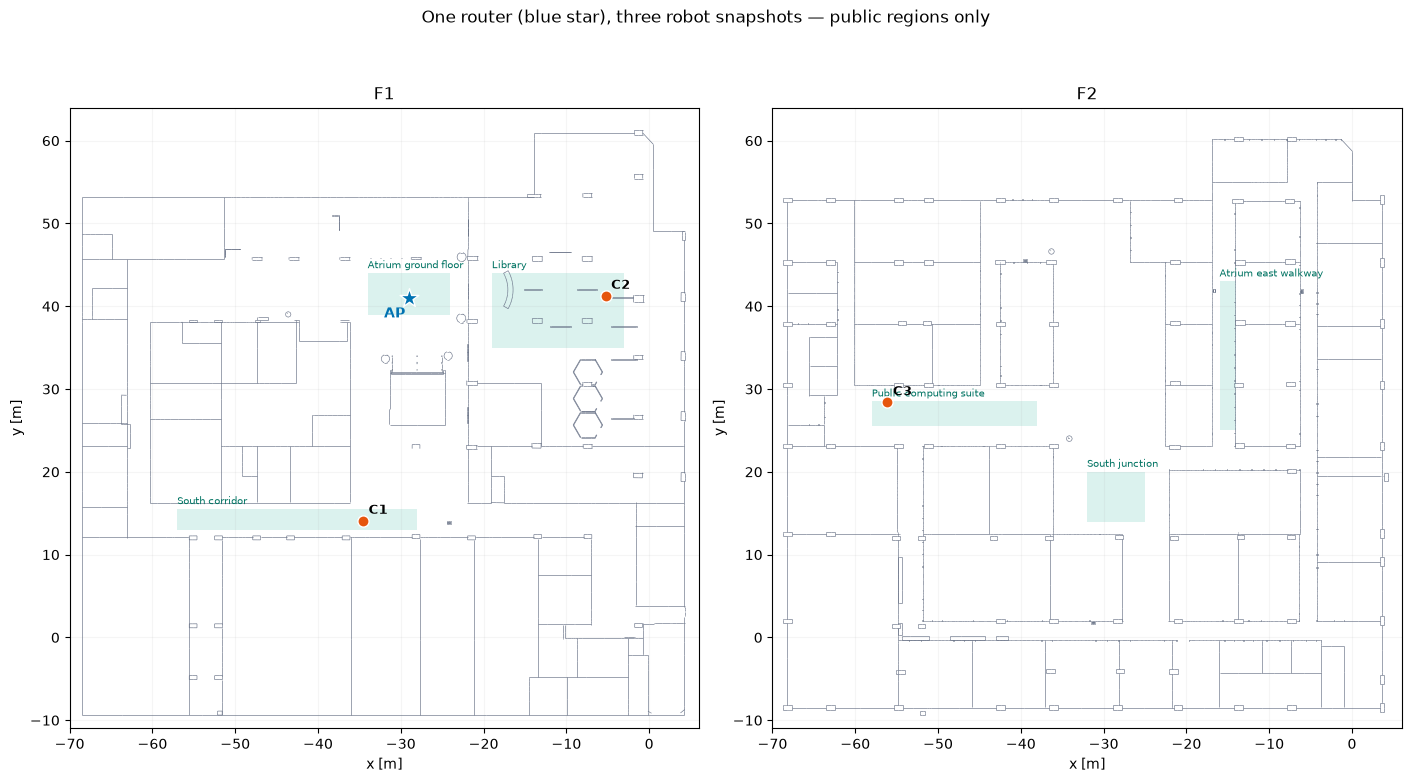

In [4]:
# Slice the existing meshes, rather than drawing an invented floor plan.
def floor_segments(z):
    segments = []
    for mesh in scene.mi_scene.shapes():
        params = mi.traverse(mesh)
        vertices = np.asarray(params["vertex_positions"]).reshape(-1, 3)
        triangles = vertices[np.asarray(params["faces"]).reshape(-1, 3)]
        triangles = triangles[(triangles[:, :, 2].min(1) < z) & (triangles[:, :, 2].max(1) > z)]
        intersections = np.full((len(triangles), 3, 2), np.nan)
        for e, (a, b) in enumerate(((0, 1), (1, 2), (2, 0))):
            p, q = triangles[:, a], triangles[:, b]
            crosses = (p[:, 2] < z) != (q[:, 2] < z)
            t = (z - p[crosses, 2]) / (q[crosses, 2] - p[crosses, 2])
            intersections[crosses, e] = (p[crosses] + t[:, None] * (q[crosses] - p[crosses]))[:, :2]
        # Each straddling triangle has exactly two crossing edges.
        segments.extend(intersections[np.isfinite(intersections).all(-1)].reshape(-1, 2, 2))
    return np.asarray(segments)

floor_lines = {f: floor_segments(info["surface_z"] + ANTENNA_HEIGHT_M) for f, info in FLOORS.items()}

def draw_floor(ax, floor, show_regions=True):
    ax.add_collection(LineCollection(floor_lines[floor], colors="#667085", linewidths=0.45, zorder=2))
    if show_regions:
        for r in REGIONS:
            if r["floor"] == floor:
                x0, x1, y0, y1 = r["bounds"]
                ax.add_patch(Rectangle((x0, y0), x1-x0, y1-y0, facecolor="#00a68a", alpha=0.14))
                ax.text(x0, y1+0.6, r["name"], fontsize=7, color="#007362")
    for n in nodes:
        if n["floor"] == floor:
            x, y = n["position"][:2]
            ax.scatter(x, y, s=65, color="#e6550d", edgecolor="white", zorder=5)
            ax.annotate(n["name"], (x, y), xytext=(4, 5), textcoords="offset points", fontsize=9, weight="bold", zorder=6)
    if floor == AP_FLOOR:
        ax.scatter(*AP_POSITION[:2], marker="*", s=200, c="#0072b2", edgecolor="white", zorder=7)
        ax.annotate("AP", AP_POSITION[:2], xytext=(-18, -14), textcoords="offset points", weight="bold", color="#0072b2")
    ax.set(xlim=(-70, 6), ylim=(-11, 64), aspect="equal", xlabel="x [m]", ylabel="y [m]", title=floor)
    ax.grid(alpha=0.12)

fig, axes = plt.subplots(1, 2, figsize=(14, 8), layout="constrained")
for ax, floor in zip(axes, FLOORS):
    draw_floor(ax, floor)
fig.suptitle("One router (blue star), three robot snapshots — public regions only")
plt.show()

## Frequency-dependent materials and antennas

The XML contains **fixed 2.400 GHz material values**. Merely changing `scene.frequency` would leave those values unchanged. For **both actual centre frequencies**, recompute relative permittivity as `a × f_GHz**b` and conductivity as `c × f_GHz**d` using the existing [material manifest](../../assets/sionna/material_manifest.json). Geometry, material thickness and scattering coefficients remain those of the export. No separate 5 GHz mesh export is needed. Provisional material proxies remain uncalibrated even inside their documented frequency ranges.

A normalized omnidirectional surrogate uses power pattern `G_peak × sin(theta)**q`, choosing q so its spherical mean is one. Higher peak gain means a narrower elevation lobe. Peak gains are included in the antenna patterns; only external feed losses are applied afterwards. Do not add the peak gains or antenna efficiency a second time. Physical antenna spacing is converted to wavelength units separately for each band. Both array orientations are zero (elements along world y; upright polarization).

In [5]:
def omni_surrogate(*, polarization, peak_dbi):
    # ponytail: a lossless, smooth collinear-like lobe cannot capture a real
    # antenna's sidelobes, efficiency or robot-body coupling; replace with measured patterns.
    peak = 10**(peak_dbi/10)
    low, high = 0.0, 10_000.0
    for _ in range(60):
        q = (low+high)/2
        log_directivity = math.log(2) - .5*math.log(math.pi) + math.lgamma((q+3)/2) - math.lgamma((q+2)/2)
        if log_directivity < math.log(peak):
            low = q
        else:
            high = q
    q = (low+high)/2
    def vertical_pattern(theta, phi):
        amplitude = math.sqrt(peak) * dr.maximum(dr.sin(theta), 0)**(q/2)
        return mi.Complex2f(amplitude, 0)
    # Independent numerical power integral verifies passive normalization.
    theta = np.linspace(0, np.pi, 4001)
    np.testing.assert_allclose(np.trapezoid(peak*np.sin(theta)**(q+1), theta)/2, 1, atol=2e-5)
    return PolarizedAntennaPattern(v_pattern=vertical_pattern, polarization=polarization)

register_antenna_pattern("wifi_omni_surrogate", omni_surrogate)

def set_band(band):
    frequency = band["frequency_hz"]
    scene.frequency = frequency
    f_ghz = frequency / 1e9
    extrapolated = []
    for name, material in scene.radio_materials.items():
        spec = manifest[name]
        a, b, c, d = spec["coefficients"]
        material.relative_permittivity = float(a * f_ghz**b)
        material.conductivity = float(c * f_ghz**d)
        lo, hi = spec["documented_frequency_range_GHz"]
        if not lo <= f_ghz <= hi:
            extrapolated.append(name)
    wavelength = 299_792_458 / frequency
    ap_array = PlanarArray(num_rows=1, num_cols=AP_ANTENNAS,
                          horizontal_spacing=AP_SPACING_M/wavelength, pattern="wifi_omni_surrogate", polarization="V", peak_dbi=band["ap_gain_dbi"])
    client_array = PlanarArray(num_rows=1, num_cols=CLIENT_ANTENNAS,
                              horizontal_spacing=CLIENT_SPACING_M/wavelength, pattern="wifi_omni_surrogate", polarization="V", peak_dbi=band["client_gain_dbi"])
    return ap_array, client_array, extrapolated

# Check coefficient units against the original 2.400 GHz export.
for spec in manifest.values():
    a, b, c, d = spec["coefficients"]
    expected = spec["bands"]["2400MHz"]
    np.testing.assert_allclose([a*2.4**b, c*2.4**d],
                               [expected["relative_permittivity"], expected["conductivity_S_per_m"]], rtol=1e-6)
print("Material-model self-check passed at the export reference frequency.")

Material-model self-check passed at the export reference frequency.


## Signal power, thermal-noise SNR and MIMO diagnostics

Ray tracing returns an unnormalized complex frequency-response matrix `H(f)` for each link. The OFDM-band approximation samples it uniformly across the configured bandwidth and averages **linear power**. It is not an 802.11n/ac subcarrier grid or a coded packet simulation. Increase frequency samples to check narrow notches.

For total conducted transmit power P and Nt independent equal-power transmit chains, the **mean received power per RF chain** is `P × mean_f(||H||²_F / (Nt × Nr))`, including the gain/feed correction. This explicit convention avoids counting TX power once per antenna. The driver may report a selected/combined/per-chain RSSI; do not assume its RSSI is this same quantity. Noise per receiving chain is `kTB × noise_figure`, referred to the card/router RF connector after its external pigtail. Both endpoint feed losses affect signal; the entered connector-referred noise figure includes the receiver's internal losses.

The idealized rate is `B × mean_f(sum(log2(1 + P × eigenvalues(H Hᴴ)/(Nt × noise))))`, with corrected H. It assumes equal transmit power, uncorrelated receiver noise, ideal channel knowledge and Gaussian signaling. It is an **information-theoretic benchmark**, not a Wi-Fi PHY rate or TCP/UDP throughput. No MCS sensitivity or packet-error thresholds are invented for this hardware without a verified per-MCS PER/sensitivity reference.

Specular reflections, transmission and diffraction are enabled; diffuse scattering is off. The synthetic-array approximation applies local phase offsets around each array centre. It does not model antenna coupling or separate blockage at each element. Finite path search can produce forward/reverse discrepancies; compare **channel gains**, removing the different router/client TX powers, to detect this. Zero discovered power remains `−inf`, not artificial coverage.

**Numerical failures:** the current Sionna diffraction calculation produced non-finite coefficients at an atrium grid point even with the native dipole antenna; disabling diffraction removed that failure in a diagnostic run. The notebook retains diffraction, explicitly marks affected locations invalid and excludes their signal/rate estimates. Invalid channels are distinct from zero discovered paths. It does not silently replace an invalid result with zero power or a no-diffraction result.

In [6]:
def power_db(value):
    value = np.asarray(value, dtype=float)
    if np.any(~np.isfinite(value)) or np.any(value < 0):
        raise ValueError("Power must be finite and nonnegative.")
    with np.errstate(divide="ignore"):
        return 10 * np.log10(value)

def link_metrics(h, offsets, tx_dbm, noise_figure_db, correction_db):
    # h axes: link, RX antenna, TX antenna, frequency.
    nr, nt = h.shape[1:3]
    bandwidth = float(offsets[-1] - offsets[0])
    if not np.isfinite(bandwidth) or bandwidth <= 0:
        raise ValueError("Need positive finite bandwidth.")
    invalid = ~np.isfinite(h).all(axis=(1, 2, 3))
    # SVD cannot process NaN. Use a temporary zero only for computation, then
    # return NaN + an explicit invalid flag; never report these links as outages.
    h = np.where(invalid[:, None, None, None], 0, h)
    correction = 10**(correction_db/10)
    mean_gain = np.trapezoid(np.sum(np.abs(h)**2, axis=(1, 2))/(nr*nt), offsets, axis=-1)/bandwidth
    gain_db = power_db(mean_gain) + correction_db
    noise_w = 1.380649e-23 * TEMPERATURE_K * bandwidth * 10**(noise_figure_db/10)
    noise_dbm = float(power_db(noise_w) + 30)
    rss_dbm = tx_dbm + gain_db
    # Batched SVD: link, frequency, RX, TX -> per-frequency singular values.
    singular_values = np.linalg.svd(h.transpose(0, 3, 1, 2), compute_uv=False)
    mode_power = singular_values**2 * correction
    rho = 10**((tx_dbm-30)/10) / (nt*noise_w)
    efficiency = np.trapezoid(np.sum(np.log2(1 + rho*mode_power), axis=-1), offsets, axis=-1)/bandwidth
    # Average modal powers over frequency; low second/first ratio means a weak second mode.
    modes = np.trapezoid(mode_power, offsets, axis=1)/bandwidth
    ratio_db = np.full(len(h), np.nan)
    if min(nr, nt) > 1:
        valid = modes[:, 0] > 0
        ratio_db[valid] = power_db(modes[valid, 1]/modes[valid, 0])
    metrics = dict(gain_db=gain_db, rss_dbm=rss_dbm, snr_db=rss_dbm-noise_dbm,
                   ideal_mbps=bandwidth*efficiency/1e6, mode_ratio_db=ratio_db)
    for values in metrics.values():
        values[invalid] = np.nan
    return dict(**metrics, noise_dbm=noise_dbm, invalid=invalid)

def trace_link(rt_scene, tx_position, rx_positions, band, tx_dbm, rx_nf_db, correction_db, *, los_only=False):
    tx_position = np.asarray(tx_position, dtype=float).reshape(3)
    rx_positions = np.asarray(rx_positions, dtype=float).reshape(-1, 3)
    if not len(rx_positions) or not np.isfinite(rx_positions).all() or not np.isfinite(tx_position).all():
        raise ValueError("Need finite transmitter and receiver positions.")
    if np.any(np.linalg.norm(rx_positions-tx_position, axis=1) < 0.5):
        raise ValueError("Exclude receivers within 0.5 m of the transmitter.")
    if rt_scene.transmitters or rt_scene.receivers:
        raise ValueError("Scene must have no existing radio devices.")
    offsets = np.linspace(-band["bandwidth_hz"]/2, band["bandwidth_hz"]/2, N_FREQ_SAMPLES)
    try:
        rt_scene.add(Transmitter(name="probe_tx", position=tx_position, power_dbm=tx_dbm))
        for j, p in enumerate(rx_positions):
            rt_scene.add(Receiver(name=f"probe_rx_{j}", position=p))
        paths = solver(scene=rt_scene, max_depth=0 if los_only else MAX_DEPTH,
                       samples_per_src=1 if los_only else SAMPLES_PER_SRC, los=True,
                       specular_reflection=not los_only, refraction=not los_only,
                       diffraction=ENABLE_DIFFRACTION and not los_only, diffuse_reflection=False,
                       synthetic_array=True, seed=SEED)
        h = paths.cfr(frequencies=mi.Float(offsets), normalize=False, out_type="numpy")
        assert h.shape[0] == len(rx_positions) and h.shape[2] == 1 and h.shape[4] == 1
        metrics = link_metrics(h[:, :, 0, :, 0, :], offsets, tx_dbm, rx_nf_db, correction_db)
        if metrics["invalid"].any():
            print("Numerically invalid channel at RX coordinates (excluded from results):",
                  rx_positions[metrics["invalid"]].round(3).tolist())
        return metrics
    finally:
        for name in list(rt_scene.transmitters) + list(rt_scene.receivers):
            rt_scene.remove(name)

# Independent checks: absolute free-space power, frequency loss, and MIMO power splitting.
free = load_scene()
check_gains = []
for band in BANDS.values():
    free.frequency = band["frequency_hz"]
    free.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="wifi_omni_surrogate", polarization="V", peak_dbi=band["ap_gain_dbi"])
    free.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="wifi_omni_surrogate", polarization="V", peak_dbi=band["client_gain_dbi"])
    correction = -band["ap_feed_db"] - band["client_feed_db"]
    result = trace_link(free, [0, 0, 0], [[10, 0, 0], [20, 0, 0]], band,
                        band["ap_tx_dbm"], CLIENT_NOISE_FIGURE_DB, correction, los_only=True)
    wavelength = 299_792_458 / band["frequency_hz"]
    friis = (band["ap_tx_dbm"] + band["ap_gain_dbi"] + band["client_gain_dbi"]
             - band["ap_feed_db"] - band["client_feed_db"] - 20*np.log10(4*np.pi*np.array([10, 20])/wavelength))
    np.testing.assert_allclose(result["rss_dbm"], friis, atol=0.05)
    check_gains.append(result["gain_db"][0] - correction - band["ap_gain_dbi"] - band["client_gain_dbi"])
frequencies = [b["frequency_hz"] for b in BANDS.values()]
np.testing.assert_allclose(check_gains[1]-check_gains[0], -20*np.log10(frequencies[1]/frequencies[0]), atol=0.05)
offsets = np.linspace(-10e6, 10e6, 3)
identity_h = np.repeat(np.eye(2)[None, :, :, None], 3, axis=-1).astype(complex)
identity = link_metrics(identity_h, offsets, 0, 0, 0)
np.testing.assert_allclose(identity["gain_db"], 10*np.log10(0.5), atol=1e-8)
noise = 1.380649e-23 * TEMPERATURE_K * 20e6
np.testing.assert_allclose(identity["ideal_mbps"], 20 * 2*np.log2(1+0.001/(2*noise)), rtol=1e-8)
zero = link_metrics(np.zeros_like(identity_h), offsets, 0, 0, 0)
assert np.isneginf(zero["rss_dbm"]).all() and (zero["ideal_mbps"] == 0).all()
invalid_h = identity_h.copy()
invalid_h[0, 0, 0, 0] = np.nan
invalid_test = link_metrics(invalid_h, offsets, 0, 0, 0)
assert invalid_test["invalid"].all() and np.isnan(invalid_test["rss_dbm"]).all()
assert np.isnan(invalid_test["ideal_mbps"]).all() and not zero["invalid"].any()
assert not free.transmitters and not free.receivers
print("PHY self-check passed: Friis on both bands, distance/frequency loss, fixed total MIMO power, zero paths, numerical-failure masking.")

PHY self-check passed: Friis on both bands, distance/frequency loss, fixed total MIMO power, zero paths, numerical-failure masking.


## Router downlink and Jetson uplink

One router-to-all-location solve and three separate client-to-router solves are performed per band. No clients transmit concurrently. TX powers differ intentionally; reciprocity checks compare the normalized mean channel gain, not the raw uplink and downlink RSS. Large discrepancies flag a propagation-search/model problem, not inherently one-way radio hardware. Passing this check alone does not establish convergence or calibration.

In [7]:
results = {}
for name, band in BANDS.items():
    ap_array, client_array, extrapolated = set_band(band)
    correction = -band["ap_feed_db"] - band["client_feed_db"]
    scene.tx_array, scene.rx_array = ap_array, client_array
    down = trace_link(scene, AP_POSITION, positions, band, band["ap_tx_dbm"], CLIENT_NOISE_FIGURE_DB, correction)
    scene.tx_array, scene.rx_array = client_array, ap_array
    up_rows = []
    for i, p in enumerate(positions):
        up_rows.append(trace_link(scene, p, [AP_POSITION], band, band["client_tx_dbm"], AP_NOISE_FIGURE_DB, correction))
        print(f"{name}: {labels[i]} uplink complete")
    up = {k: np.concatenate([r[k] for r in up_rows]) for k in down if k != "noise_dbm"}
    up["noise_dbm"] = up_rows[0]["noise_dbm"]
    finite = np.isfinite(down["gain_db"]) & np.isfinite(up["gain_db"])
    discrepancy = np.full(N_NODES, np.inf)
    discrepancy[finite] = np.abs(down["gain_db"][finite] - up["gain_db"][finite])
    unresolved = discrepancy > RECIPROCITY_TOL_DB
    results[name] = dict(down=down, up=up, correction_db=correction, discrepancy_db=discrepancy)
    print(f"{name}: noise per RX chain DL={down['noise_dbm']:.1f}, UL={up['noise_dbm']:.1f} dBm; "
          f"material proxies outside documented frequency range: {len(extrapolated)}")
    if unresolved.any():
        names = ", ".join(np.array(labels)[unresolved])
        display(Markdown(f"**{name}: exploratory/unconverged** at {names}. Channel gain differs by "
                         f">{RECIPROCITY_TOL_DB:g} dB by direction, or a channel was missing/numerically invalid. "
                         "Increase samples/depth, compare seeds, and inspect geometry/materials before coverage claims."))
    else:
        print("Reciprocity screen passed; sample/seed convergence and hardware calibration still required.")
    assert all((np.isfinite(r["rss_dbm"]) | np.isneginf(r["rss_dbm"]) | r["invalid"]).all() for r in (down, up))

2.4 GHz: C1 uplink complete


2.4 GHz: C2 uplink complete


2.4 GHz: C3 uplink complete
2.4 GHz: noise per RX chain DL=-94.0, UL=-94.0 dBm; material proxies outside documented frequency range: 0
Reciprocity screen passed; sample/seed convergence and hardware calibration still required.


5 GHz: C1 uplink complete


5 GHz: C2 uplink complete


5 GHz: C3 uplink complete
5 GHz: noise per RX chain DL=-94.0, UL=-94.0 dBm; material proxies outside documented frequency range: 0


**5 GHz: exploratory/unconverged** at C2, C3. Channel gain differs by >3 dB by direction, or a channel was missing/numerically invalid. Increase samples/depth, compare seeds, and inspect geometry/materials before coverage claims.

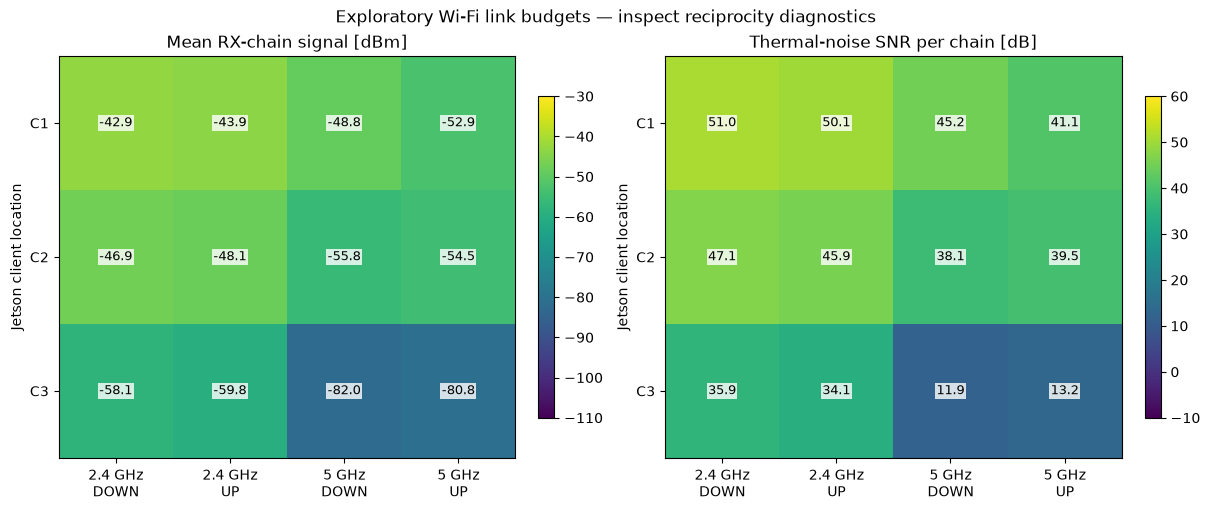

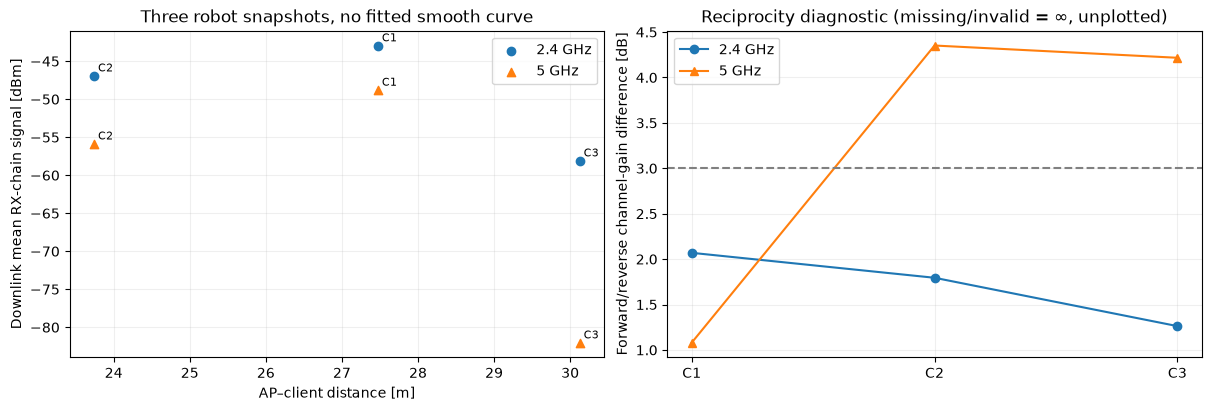

In [8]:
# Each column is a band/direction combination; rows are client locations.
columns = [f"{name}\n{direction.upper()}" for name in BANDS for direction in ("down", "up")]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
for ax, metric, title, limits in zip(axes, ("rss_dbm", "snr_db"),
                                   ("Mean RX-chain signal [dBm]", "Thermal-noise SNR per chain [dB]"),
                                   ((-110, -30), (-10, 60))):
    values = np.column_stack([results[name][direction][metric] for name in BANDS for direction in ("down", "up")])
    im = ax.imshow(np.ma.masked_invalid(values), cmap="viridis", vmin=limits[0], vmax=limits[1], aspect="auto")
    for i in range(N_NODES):
        for j in range(4):
            text = f"{values[i,j]:.1f}" if np.isfinite(values[i,j]) else ("no path" if np.isneginf(values[i,j]) else "invalid")
            ax.text(j, i, text, ha="center", va="center", fontsize=9,
                    bbox=dict(facecolor="white", alpha=.8, edgecolor="none", pad=1))
    ax.set(xticks=range(4), xticklabels=columns, yticks=range(N_NODES), yticklabels=labels,
           ylabel="Jetson client location", title=title)
    fig.colorbar(im, ax=ax, shrink=.8)
fig.suptitle("Exploratory Wi-Fi link budgets — inspect reciprocity diagnostics")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
distances = np.linalg.norm(positions-AP_POSITION, axis=1)
for name, marker in zip(BANDS, ("o", "^")):
    y = results[name]["down"]["rss_dbm"]
    finite = np.isfinite(y)
    axes[0].scatter(distances[finite], y[finite], marker=marker, label=name)
    for i in np.flatnonzero(finite):
        axes[0].annotate(labels[i], (distances[i], y[i]), xytext=(3, 3), textcoords="offset points", fontsize=8)
    axes[1].plot(labels, results[name]["discrepancy_db"], marker=marker, label=name)
axes[0].set(xlabel="AP–client distance [m]", ylabel="Downlink mean RX-chain signal [dBm]", title="Three robot snapshots, no fitted smooth curve")
axes[1].axhline(RECIPROCITY_TOL_DB, ls="--", color="grey")
axes[1].set(ylabel="Forward/reverse channel-gain difference [dB]", title="Reciprocity diagnostic (missing/invalid = ∞, unplotted)")
for ax in axes:
    ax.legend(); ax.grid(alpha=.2)
plt.show()

## What the two-antenna channel supports in the idealized model

The second/first eigenmode power ratio indicates channel rank quality. A deeply negative ratio means the second spatial mode is weak; merely having two antenna connectors does not ensure two useful streams. The next chart reports the **downlink Gaussian-signaling benchmark** defined above, without Wi-Fi MCS restrictions, pilots, coding loss, MAC overhead, retransmissions or transport overhead. It can exceed a device's supported PHY rate and must not be quoted as throughput. The kernel/driver do not participate in ray tracing.

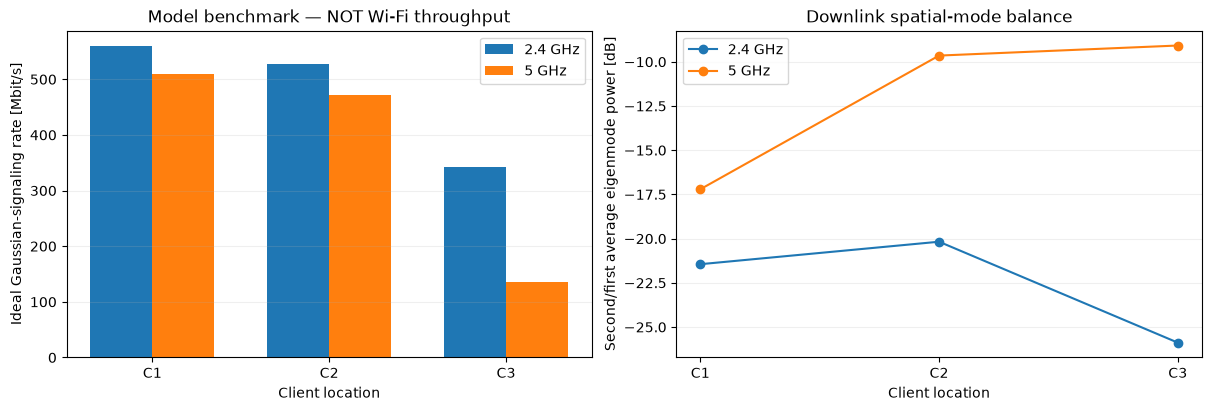

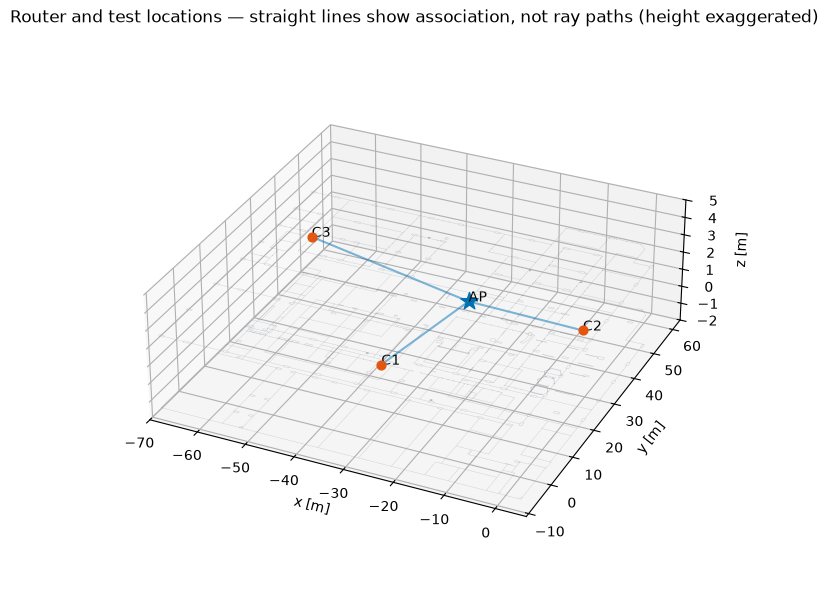

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
x = np.arange(N_NODES)
for i, (name, r) in enumerate(results.items()):
    axes[0].bar(x+(i-.5)*.35, r["down"]["ideal_mbps"], width=.35, label=name)
    axes[1].plot(x, r["down"]["mode_ratio_db"], marker="o", label=name)
axes[0].set(ylabel="Ideal Gaussian-signaling rate [Mbit/s]", title="Model benchmark — NOT Wi-Fi throughput")
axes[1].set(ylabel="Second/first average eigenmode power [dB]", title="Downlink spatial-mode balance")
if min(AP_ANTENNAS, CLIENT_ANTENNAS) == 1:
    axes[1].text(.5, .5, "One chain: no second spatial mode", transform=axes[1].transAxes, ha="center")
for ax in axes:
    ax.set(xticks=x, xticklabels=labels, xlabel="Client location")
    ax.grid(axis="y", alpha=.2); ax.legend()
plt.show()

from mpl_toolkits.mplot3d.art3d import Line3DCollection
fig = plt.figure(figsize=(11, 6), layout="constrained")
ax = fig.add_subplot(111, projection="3d")
for floor, lines in floor_lines.items():
    xyz = np.concatenate([lines, np.full((*lines.shape[:2], 1), FLOORS[floor]["surface_z"])], axis=-1)
    ax.add_collection3d(Line3DCollection(xyz, colors="#8c929c", linewidths=.3, alpha=.4))
ax.scatter(*AP_POSITION, marker="*", s=170, c="#0072b2")
ax.text(*AP_POSITION, "AP")
for n in nodes:
    ax.scatter(*n["position"], c="#e6550d", s=40)
    ax.text(*n["position"], n["name"])
    ax.plot(*np.array([AP_POSITION, n["position"]]).T, c="#0072b2", alpha=.5)
ax.set(xlim=(-70, 6), ylim=(-11, 64), zlim=(-2, 5), xlabel="x [m]", ylabel="y [m]", zlabel="z [m]",
       title="Router and test locations — straight lines show association, not ray paths (height exaggerated)")
ax.set_box_aspect((1, 1, .35)); ax.view_init(elev=30, azim=-65)
plt.show()

## Downlink radio environment maps: two bands × two floors

Trace additional **virtual client locations** using the same client array, height and feed losses. The same valid grid is reused on both bands. White means unsampled/rejected geometry, black × means no path was discovered, red + means a numerical failure (no valid prediction), and colors show sampled cell values on a common dBm scale. Only the audited public regions are mapped, not the entire building. These virtual receivers do not add network traffic.

Reduce `MAP_STEP_M` for a finer gradient. No interpolation crosses walls or excluded rooms. The default 2 m grid is much coarser than the wavelength on either Wi-Fi band and does not resolve small-scale fading. A smooth large-scale map needs denser samples and local averaging in linear power **within each public region**. For a wider channel comparison, change both bandwidth and centre frequency appropriately and rerun from configuration: bandwidth changes the noise as well as frequency averaging. These are fixed-height floor slices, not a sampled 3D field.

2.4 GHz: South corridor, 30 virtual client locations


2.4 GHz: Library, 30 virtual client locations


Numerically invalid channel at RX coordinates (excluded from results): [[-33.0, 39.833, -0.137]]
2.4 GHz: Atrium ground floor, 15 virtual client locations


2.4 GHz: Public computing suite, 20 virtual client locations


2.4 GHz: Atrium east walkway, 9 virtual client locations


...

5 GHz: Library, 30 virtual client locations


Numerically invalid channel at RX coordinates (excluded from results): [[-33.0, 39.833, -0.137]]
5 GHz: Atrium ground floor, 15 virtual client locations


5 GHz: Public computing suite, 20 virtual client locations


5 GHz: Atrium east walkway, 9 virtual client locations


5 GHz: South junction, 8 virtual client locations


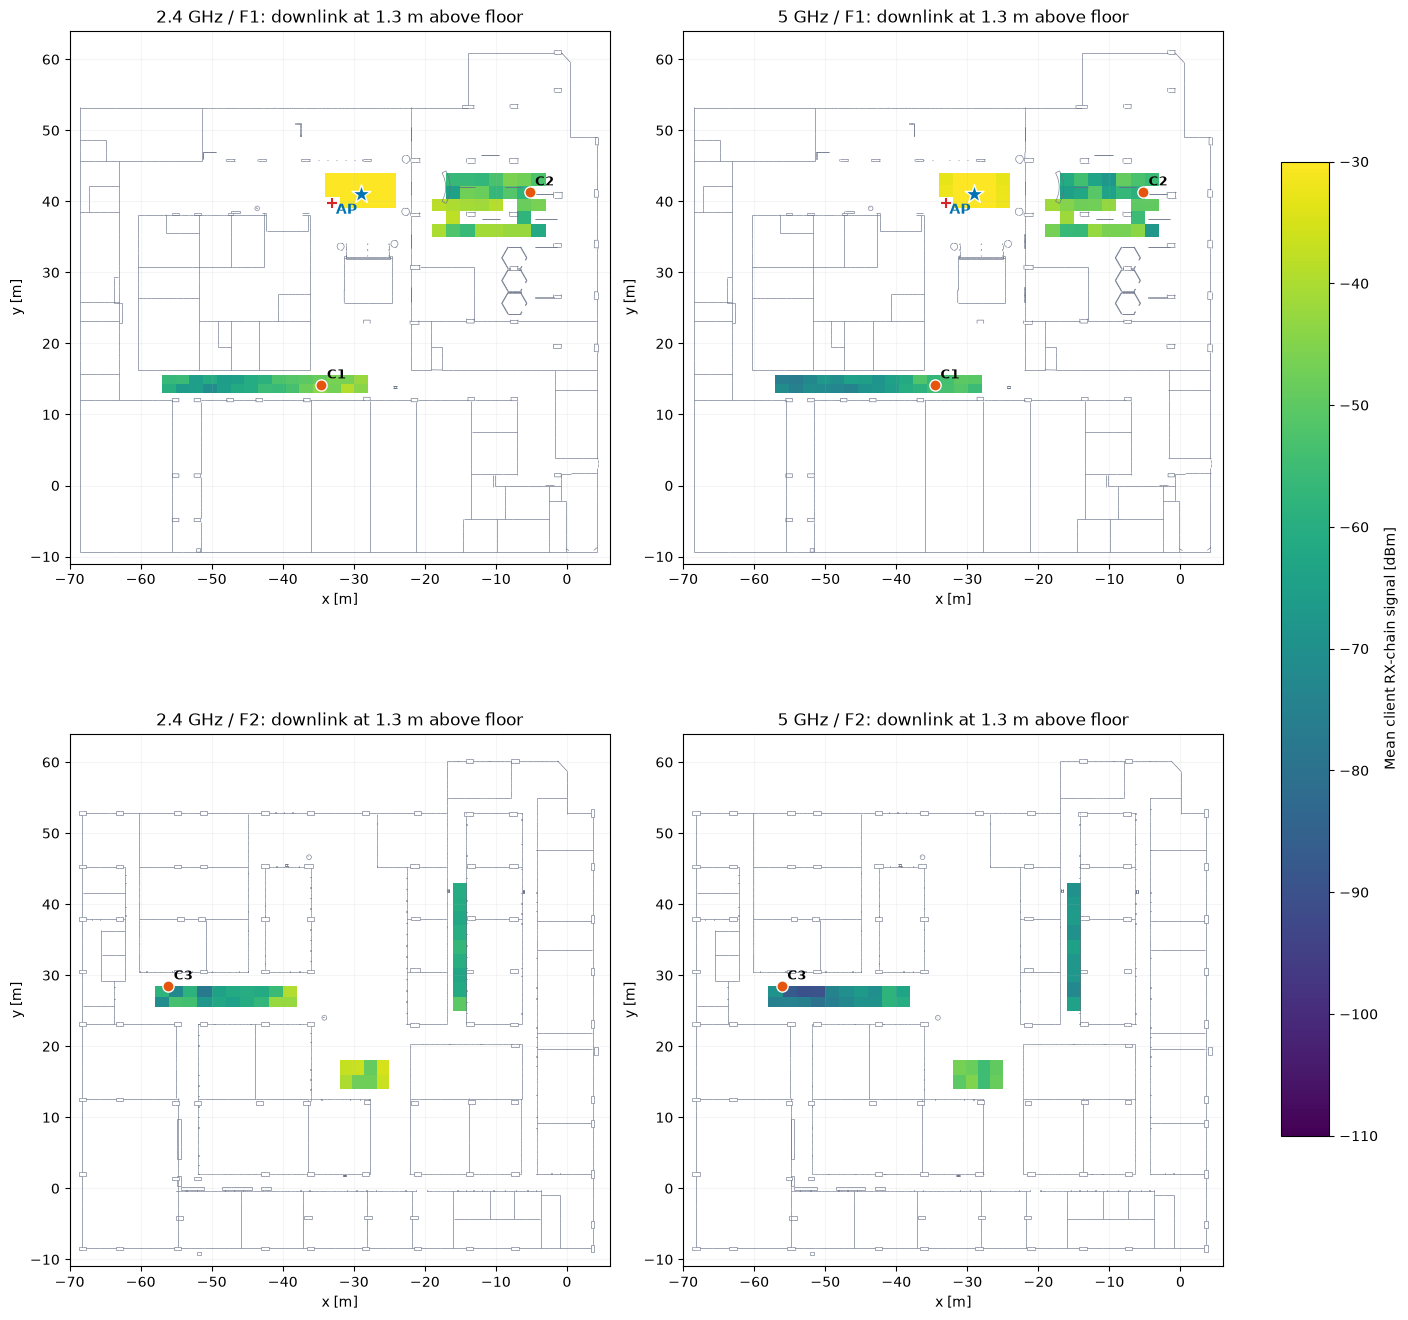

In [10]:
map_results = {}
if RUN_MAPS:
    grids = []
    for region in REGIONS:
        x0, x1, y0, y1 = region["bounds"]
        nx, ny = max(1, int(np.ceil((x1-x0)/MAP_STEP_M))), max(1, int(np.ceil((y1-y0)/MAP_STEP_M)))
        xe, ye = np.linspace(x0, x1, nx+1), np.linspace(y0, y1, ny+1)
        xx, yy = np.meshgrid((xe[:-1]+xe[1:])/2, (ye[:-1]+ye[1:])/2)
        points = np.column_stack([xx.ravel(), yy.ravel(), np.full(xx.size, FLOORS[region["floor"]]["surface_z"]+ANTENNA_HEIGHT_M)])
        valid = geometry_clear(points, region["floor"])
        valid &= np.linalg.norm(points-AP_POSITION, axis=1) >= .5
        grids.append(dict(region=region, xe=xe, ye=ye, points=points, valid=valid, shape=xx.shape))
    for name, band in BANDS.items():
        ap_array, client_array, _ = set_band(band)
        scene.tx_array, scene.rx_array = ap_array, client_array
        maps = []
        for grid in grids:
            values = np.full(len(grid["points"]), np.nan)
            indices = np.flatnonzero(grid["valid"])
            for start in range(0, len(indices), MAP_BATCH_SIZE):
                batch = indices[start:start+MAP_BATCH_SIZE]
                values[batch] = trace_link(scene, AP_POSITION, grid["points"][batch], band,
                                          band["ap_tx_dbm"], CLIENT_NOISE_FIGURE_DB,
                                          results[name]["correction_db"])["rss_dbm"]
            maps.append(values.reshape(grid["shape"]))
            print(f"{name}: {grid['region']['name']}, {len(indices)} virtual client locations")
        map_results[name] = maps
    fig, axes = plt.subplots(2, 2, figsize=(14, 14), layout="constrained")
    for row, floor in enumerate(FLOORS):
        for col, name in enumerate(BANDS):
            ax = axes[row, col]
            for grid, values in zip(grids, map_results[name]):
                if grid["region"]["floor"] != floor:
                    continue
                im = ax.pcolormesh(grid["xe"], grid["ye"], np.ma.masked_invalid(values),
                                   cmap="viridis", vmin=-110, vmax=-30, shading="flat")
                missing = np.isneginf(values.ravel())
                ax.scatter(*grid["points"][missing, :2].T, marker="x", c="black", s=12)
                invalid = grid["valid"] & np.isnan(values.ravel())
                ax.scatter(*grid["points"][invalid, :2].T, marker="+", c="#d62728", s=45, zorder=8)
            draw_floor(ax, floor, show_regions=False)
            ax.set_title(f"{name} / {floor}: downlink at {ANTENNA_HEIGHT_M:g} m above floor")
    fig.colorbar(im, ax=axes.ravel().tolist(), label="Mean client RX-chain signal [dBm]", shrink=.7)
    plt.show()
else:
    print("Set RUN_MAPS=True to trace both floor maps on both bands.")

## Optional embedded 3D preview

This is an in-notebook widget and needs working WebGL. Static plots above remain usable without it. The display uses the last band traced; geometry and device positions are common to both bands. Removing the temporary devices after display leaves the scene ready for rerunning calculations.

In [11]:
if OPEN_INTERACTIVE_PREVIEW:
    try:
        scene.add(Transmitter(name="WiFi_router", position=AP_POSITION))
        for node in nodes:
            scene.add(Receiver(name=node["name"], position=node["position"]))
        scene.preview(clip_at=4.8)
    finally:
        for name in list(scene.transmitters) + list(scene.receivers):
            scene.remove(name)

## Using this with the real Jetson

On the Jetson itself, confirm the 8260 identity and record the carrier-board interface, JetPack/kernel and firmware versions before replacing the remaining assumptions. These are optional read-only commands to run in a **Jetson terminal**, not cells that control the notebook host:

```bash
lspci -nnk
uname -r
modinfo iwlwifi
iw dev
iw phy
# Replace wlan0 with the interface listed by iw dev:
iw dev wlan0 link
iw dev wlan0 station dump
```

Confirm the exact card is supported by that kernel/firmware and carrier board; [Intel's Linux support list](https://www.intel.com/content/www/us/en/support/articles/000005511/wireless.html) and [Linux Wireless iwlwifi documentation](https://wireless.docs.kernel.org/en/latest/en/users/drivers/iwlwifi.html) are starting points, not a compatibility guarantee for your carrier board.

Record actual centre frequency, bandwidth, TX power, antenna installation, per-chain signal where available, negotiated MCS/NSS, and stationary measurements at C1–C3. The reported TX bitrate is not measured throughput, and neither can be inferred from RSS alone. Calibrate the receiver noise figure and antenna/feed assumptions against measurements. Client-to-router asymmetry from different TX power is separate from a reciprocity failure in the simulated passive channel.

To study congestion, add packet arrivals, Wi-Fi airtime, CSMA/CA, hidden nodes, interference, rate adaptation and retries in a network/packet simulator using these channel results as inputs. These 8260 clients do not gain ax OFDMA or MU-MIMO capability from the router. Scheduling is not represented by this single-client-at-a-time study. Robot motion/Doppler, robot chassis, moving people, antenna coupling and hardware implementation losses are also absent. Material proxies and finite ray-search budgets remain important limitations: do not treat a colorful map or Shannon benchmark as validated Wi-Fi coverage.